# Exercise 2_1 : Sampling from continuous distributions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import kstest, expon, norm, chi2

Part 1a: Exponential via inverse transform

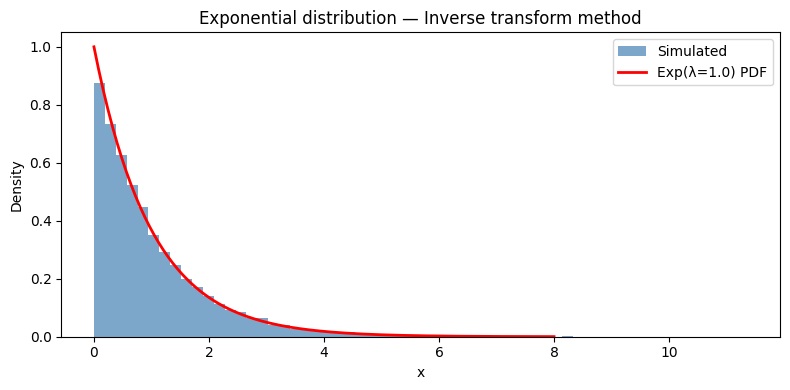

KS statistic: 0.0125
p-value:      0.0859
✓ Fail to reject H0: consistent with Exp(λ=1)


In [2]:
np.random.seed(42)
lam = 1.0
n = 10000

U = np.random.uniform(0, 1, n)
X_exp = -np.log(U) / lam  # inverse transform

# Compare with theoretical
x_range = np.linspace(0, 8, 200)
theoretical_pdf = lam * np.exp(-lam * x_range)

plt.figure(figsize=(8, 4))
plt.hist(X_exp, bins=60, density=True, alpha=0.7, 
         color='steelblue', label='Simulated')
plt.plot(x_range, theoretical_pdf, 'r-', 
         linewidth=2, label=f'Exp(λ={lam}) PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Exponential distribution — Inverse transform method')
plt.legend()
plt.tight_layout()
plt.show()

# KS test (better than chi2 for continuous distributions)
ks_stat, p_val = kstest(X_exp, 'expon', args=(0, 1/lam))
print(f"KS statistic: {ks_stat:.4f}")
print(f"p-value:      {p_val:.4f}")
if p_val > 0.05:
    print("✓ Fail to reject H0: consistent with Exp(λ=1)")
else:
    print("✗ Reject H0")

Part 1b: Normal via Box-Muller

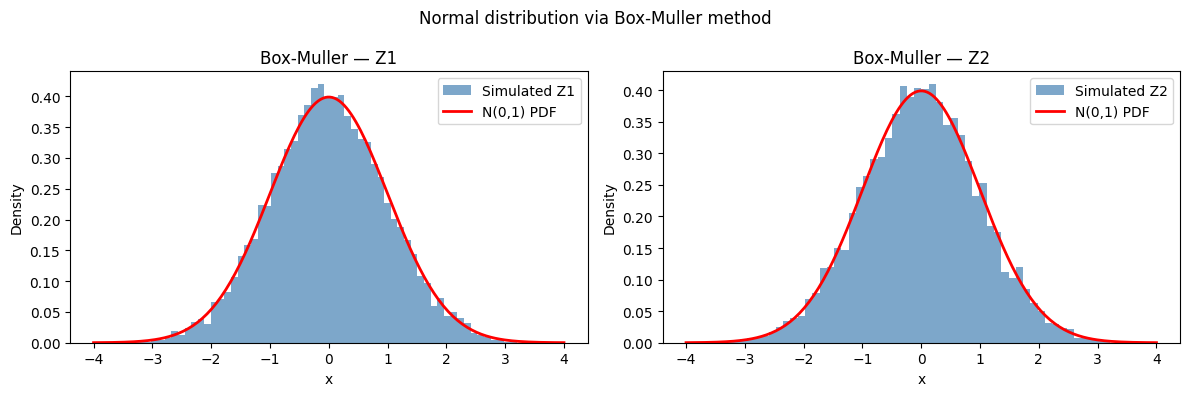

Z1: KS=0.0117, p=0.1257 — ✓ Fail to reject H0
Z2: KS=0.0072, p=0.6716 — ✓ Fail to reject H0

Correlation between Z1 and Z2: 0.0033 (should be ≈ 0)


In [3]:
U1 = np.random.uniform(0, 1, n)
U2 = np.random.uniform(0, 1, n)

# Box-Muller transform
Z1 = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)
Z2 = np.sqrt(-2 * np.log(U1)) * np.sin(2 * np.pi * U2)

# Plot both Z1 and Z2
x_range = np.linspace(-4, 4, 200)
theoretical_pdf = norm.pdf(x_range)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, Z, label in zip(axes, [Z1, Z2], ['Z1', 'Z2']):
    ax.hist(Z, bins=60, density=True, alpha=0.7, 
            color='steelblue', label=f'Simulated {label}')
    ax.plot(x_range, theoretical_pdf, 'r-', 
            linewidth=2, label='N(0,1) PDF')
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.set_title(f'Box-Muller — {label}')
    ax.legend()

plt.suptitle('Normal distribution via Box-Muller method')
plt.tight_layout()
plt.show()

# KS tests for both
for Z, label in [(Z1, 'Z1'), (Z2, 'Z2')]:
    ks_stat, p_val = kstest(Z, 'norm')
    print(f"{label}: KS={ks_stat:.4f}, p={p_val:.4f} — "
          f"{'✓ Fail to reject' if p_val > 0.05 else '✗ Reject'} H0")

# Also verify they are independent (correlation should be ~0)
corr = np.corrcoef(Z1, Z2)[0,1]
print(f"\nCorrelation between Z1 and Z2: {corr:.4f} (should be ≈ 0)")

Part 1c: Pareto via inverse transform

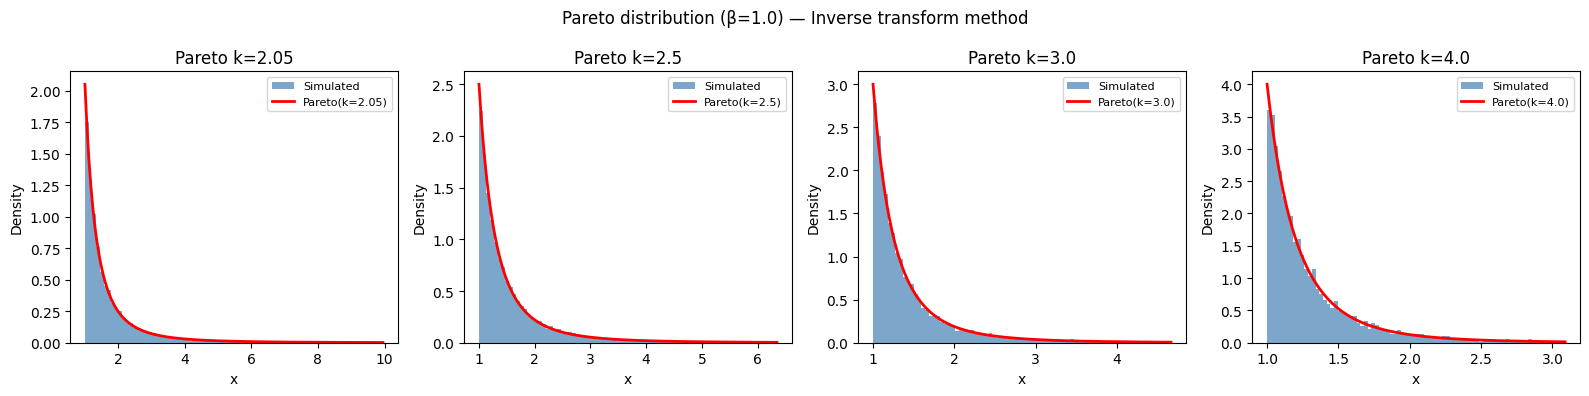

KS tests for Pareto distributions:
--------------------------------------------------
k=2.05 : KS=0.0082, p=0.5144 — ✓ Fail to reject H0
k=2.5  : KS=0.0099, p=0.2821 — ✓ Fail to reject H0
k=3.0  : KS=0.0091, p=0.3706 — ✓ Fail to reject H0
k=4.0  : KS=0.0068, p=0.7482 — ✓ Fail to reject H0


In [4]:
beta = 1.0
k_values = [2.05, 2.5, 3.0, 4.0]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, k in zip(axes, k_values):
    U = np.random.uniform(0, 1, n)
    X_pareto = beta * U**(-1/k)  # inverse transform
    
    # Theoretical PDF: f(x) = k * beta^k / x^(k+1)
    x_range = np.linspace(beta, np.percentile(X_pareto, 99), 300)
    pdf = k * beta**k / x_range**(k+1)
    
    ax.hist(X_pareto, bins=80, density=True, alpha=0.7,
            color='steelblue', label='Simulated',
            range=(beta, np.percentile(X_pareto, 99)))
    ax.plot(x_range, pdf, 'r-', linewidth=2, label=f'Pareto(k={k})')
    ax.set_title(f'Pareto k={k}')
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle(f'Pareto distribution (β={beta}) — Inverse transform method')
plt.tight_layout()
plt.show()

# KS tests for each k
print("KS tests for Pareto distributions:")
print("-" * 50)
for k in k_values:
    U = np.random.uniform(0, 1, n)
    X_pareto = beta * U**(-1/k)
    # scipy pareto: scale=beta, c=k (shape)
    ks_stat, p_val = kstest(X_pareto, 'pareto', args=(k, 0, beta))
    print(f"k={k:<5}: KS={ks_stat:.4f}, p={p_val:.4f} — "
          f"{'✓ Fail to reject' if p_val > 0.05 else '✗ Reject'} H0")

Part 2: Sample vs theoretical mean and variance

In [5]:
np.random.seed(42)
n_large = 100000  # use large n to see convergence clearly
beta = 1.0

print("=" * 75)
print(f"{'k':<8} {'E[X] true':<14} {'E[X] sim':<14} {'V[X] true':<16} {'V[X] sim'}")
print("=" * 75)

for k in k_values:
    U = np.random.uniform(0, 1, n_large)
    X = beta * U**(-1/k)
    
    mean_theoretical = (k * beta) / (k - 1)
    mean_simulated   = np.mean(X)
    
    if k > 2:
        var_theoretical = (k * beta**2) / ((k-1)**2 * (k-2))
        var_simulated   = np.var(X, ddof=1)
        var_true_str = f"{var_theoretical:.4f}"
        var_sim_str  = f"{var_simulated:.4f}"
    else:
        var_true_str = "∞ (k≤2)"
        var_sim_str  = f"{np.var(X, ddof=1):.4f} (!)"

    print(f"{k:<8} {mean_theoretical:<14.4f} {mean_simulated:<14.4f} "
          f"{var_true_str:<16} {var_sim_str}")

print("=" * 75)
print(f"\nNote: k=2.05 variance is theoretically infinite (k must be > 2)")
print(f"      The simulated variance will be large and unstable across runs")

k        E[X] true      E[X] sim       V[X] true        V[X] sim
2.05     1.9524         1.9580         37.1882          9.3400
2.5      1.6667         1.6632         2.2222           2.0763
3.0      1.5000         1.5009         0.7500           0.7935
4.0      1.3333         1.3333         0.2222           0.2177

Note: k=2.05 variance is theoretically infinite (k must be > 2)
      The simulated variance will be large and unstable across runs


Demonstrate instability of k=2.05 variance across runs

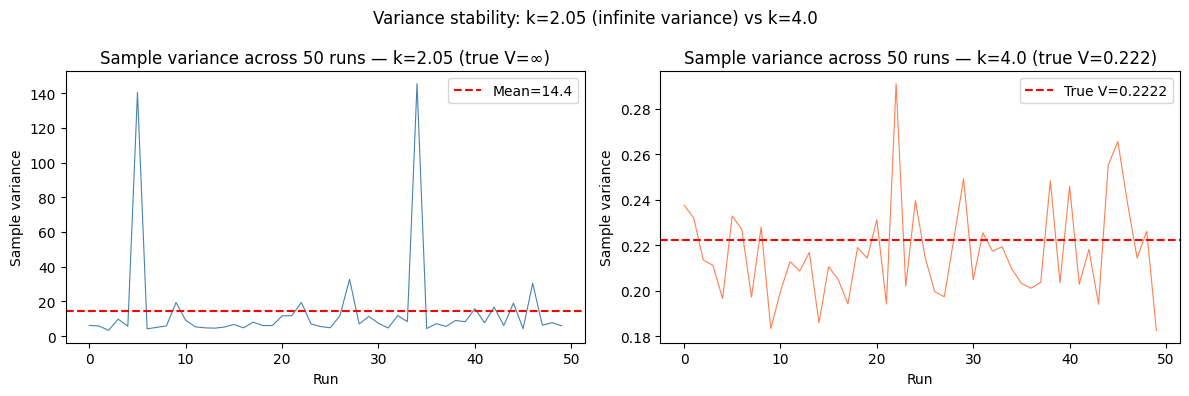

k=2.05 variance — mean: 14.40, std: 26.93, range: [3.27, 145.44]
k=4.0  variance — mean: 0.2169, std: 0.0215, range: [0.1825, 0.2910]


In [6]:
# Show that k=2.05 variance is highly unstable across repeated runs
k_unstable = 2.05
n_runs = 50
n_each = 10000

variances_205 = []
variances_40  = []

for _ in range(n_runs):
    X1 = beta * np.random.uniform(0,1,n_each)**(-1/k_unstable)
    X2 = beta * np.random.uniform(0,1,n_each)**(-1/4.0)
    variances_205.append(np.var(X1, ddof=1))
    variances_40.append(np.var(X2, ddof=1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(variances_205, color='steelblue', linewidth=0.8)
axes[0].set_title('Sample variance across 50 runs — k=2.05 (true V=∞)')
axes[0].set_xlabel('Run')
axes[0].set_ylabel('Sample variance')
axes[0].axhline(np.mean(variances_205), color='red', 
                linestyle='--', label=f'Mean={np.mean(variances_205):.1f}')
axes[0].legend()

axes[1].plot(variances_40, color='coral', linewidth=0.8)
axes[1].axhline(0.2222, color='red', linestyle='--', 
                label=f'True V=0.2222')
axes[1].set_title('Sample variance across 50 runs — k=4.0 (true V=0.222)')
axes[1].set_xlabel('Run')
axes[1].set_ylabel('Sample variance')
axes[1].legend()

plt.suptitle('Variance stability: k=2.05 (infinite variance) vs k=4.0')
plt.tight_layout()
plt.show()

print(f"k=2.05 variance — mean: {np.mean(variances_205):.2f}, "
      f"std: {np.std(variances_205):.2f}, "
      f"range: [{min(variances_205):.2f}, {max(variances_205):.2f}]")
print(f"k=4.0  variance — mean: {np.mean(variances_40):.4f}, "
      f"std: {np.std(variances_40):.4f}, "
      f"range: [{min(variances_40):.4f}, {max(variances_40):.4f}]")

The spikes in k=2.05 correspond to runs where a single extremely large value was sampled, temporarily inflating the variance. This is the signature of a heavy-tailed distribution with infinite variance

no finite sample can reliably estimate it.

Part 3: 100 Confidence Intervals for mean and variance

In [7]:
np.random.seed(42)
mu_true    = 0.0   # true mean
sigma2_true = 1.0  # true variance
n_obs  = 10        # sample size
n_CI   = 100       # number of CIs
alpha  = 0.05

t_crit  = stats.t.ppf(1 - alpha/2, df=n_obs-1)
chi2_lo = stats.chi2.ppf(alpha/2,   df=n_obs-1)
chi2_hi = stats.chi2.ppf(1-alpha/2, df=n_obs-1)

ci_mean = []
ci_var  = []

for _ in range(n_CI):
    # Generate sample using Box-Muller
    U1 = np.random.uniform(0, 1, n_obs)
    U2 = np.random.uniform(0, 1, n_obs)
    X  = np.sqrt(-2*np.log(U1)) * np.cos(2*np.pi*U2)  # N(0,1)
    
    xbar = np.mean(X)
    S2   = np.var(X, ddof=1)
    S    = np.sqrt(S2)
    
    # CI for mean
    ci_mean.append((xbar - t_crit * S/np.sqrt(n_obs),
                    xbar + t_crit * S/np.sqrt(n_obs)))
    
    # CI for variance
    ci_var.append(((n_obs-1)*S2 / chi2_hi,
                   (n_obs-1)*S2 / chi2_lo))

ci_mean = np.array(ci_mean)
ci_var  = np.array(ci_var)

# Coverage
covers_mean = np.sum((ci_mean[:,0] <= mu_true) & 
                      (mu_true <= ci_mean[:,1]))
covers_var  = np.sum((ci_var[:,0] <= sigma2_true) & 
                      (sigma2_true <= ci_var[:,1]))

print(f"Mean CI coverage:     {covers_mean}/100 = {covers_mean}%  (nominal: 95%)")
print(f"Variance CI coverage: {covers_var}/100  = {covers_var}%  (nominal: 95%)")

Mean CI coverage:     95/100 = 95%  (nominal: 95%)
Variance CI coverage: 100/100  = 100%  (nominal: 95%)


Plot all 100 CIs

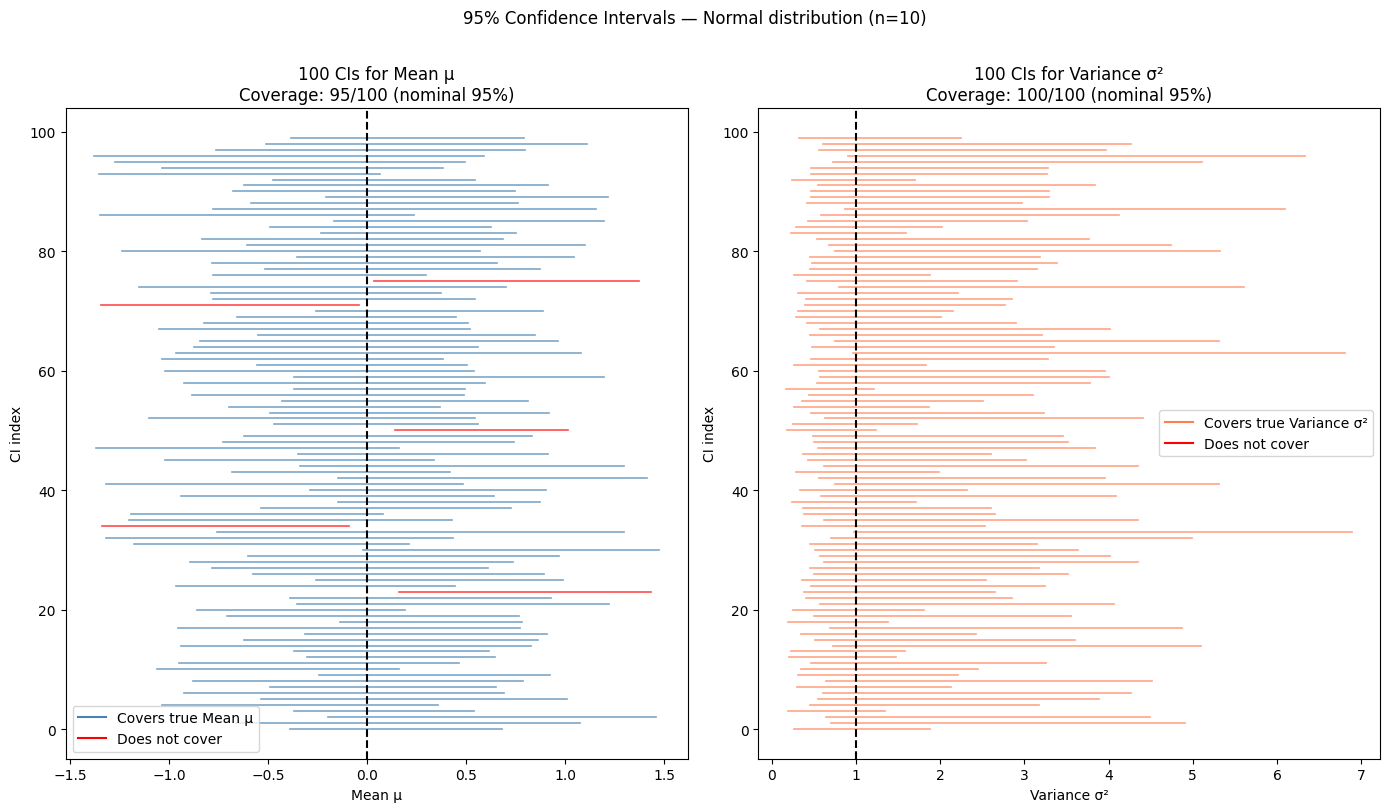

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, ci, true_val, label, color in zip(
        axes,
        [ci_mean, ci_var],
        [mu_true, sigma2_true],
        ['Mean μ', 'Variance σ²'],
        ['steelblue', 'coral']):

    covers = (ci[:,0] <= true_val) & (true_val <= ci[:,1])

    for idx in range(n_CI):
        col = color if covers[idx] else 'red'
        ax.plot([ci[idx,0], ci[idx,1]], [idx, idx], 
                color=col, linewidth=1.2, alpha=0.7)

    ax.axvline(true_val, color='black', linestyle='--', 
               linewidth=1.5, label=f'True {label}={true_val}')
    ax.set_title(f'100 CIs for {label}\n'
                 f'Coverage: {covers.sum()}/100 '
                 f'(nominal 95%)')
    ax.set_xlabel(label)
    ax.set_ylabel('CI index')
    ax.legend()

    # Highlight non-covering CIs in legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0],[0], color=color, label=f'Covers true {label}'),
        Line2D([0],[0], color='red',  label='Does not cover')
    ]
    ax.legend(handles=legend_elements)

plt.suptitle('95% Confidence Intervals — Normal distribution (n=10)', 
             y=1.01)
plt.tight_layout()
plt.show()

Part 4: Pareto via composition method

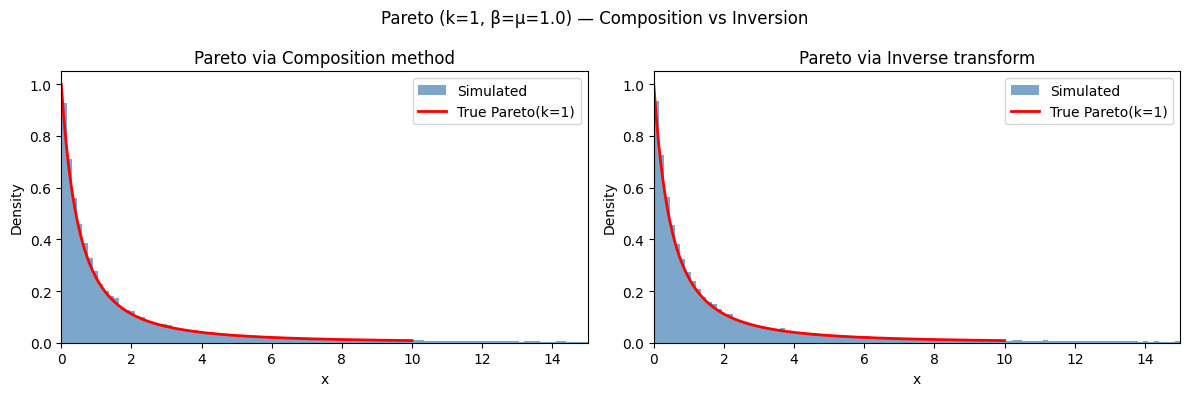

Composition: KS=0.0031, p=0.7286 — ✓ Fail to reject H0
Inversion:   KS=0.0046,  p=0.2445  — ✓ Fail to reject H0

Sample means — Composition: 16.0955, Inversion: 12.1088
True mean (k=1): undefined (infinite)


In [10]:
# Composition method for Pareto (k=1, beta=mu, support on [0,inf))
# Step 1: Y ~ Exp(mu)
# Step 2: X | Y=y ~ Exp(y)
# Result: X ~ Pareto(k=1, beta=mu) on non-negative reals
# F(x) = 1 - (1 + x/mu)^{-1}

np.random.seed(42)
mu  = 1.0
n   = 50000

# Composition method
Y_comp = np.random.exponential(scale=1/mu, size=n)  # Y ~ Exp(mu)
X_comp = np.random.exponential(scale=1/Y_comp)       # X|Y=y ~ Exp(y)

# Direct inversion: X = mu*(U^{-1/k} - 1) with k=1
U       = np.random.uniform(0, 1, n)
X_inv   = mu * (U**(-1/1.0) - 1)  # k=1

# Theoretical PDF: f(x) = mu/(mu+x)^2
x_range = np.linspace(0, 10, 300)
pdf_true = mu / (mu + x_range)**2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, X, title in zip(axes,
                         [X_comp, X_inv],
                         ['Composition method', 'Inverse transform']):
    ax.hist(X, bins=100, density=True, alpha=0.7,
            color='steelblue', range=(0, 15), label='Simulated')
    ax.plot(x_range, pdf_true, 'r-', linewidth=2,
            label='True Pareto(k=1)')
    ax.set_title(f'Pareto via {title}')
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.set_xlim(0, 15)
    ax.legend()

plt.suptitle(f'Pareto (k=1, β=μ={mu}) — Composition vs Inversion')
plt.tight_layout()
plt.show()

# KS test for both
ks_comp, p_comp = kstest(X_comp, lambda x: 1-(1+x/mu)**(-1))
ks_inv,  p_inv  = kstest(X_inv,  lambda x: 1-(1+x/mu)**(-1))

print(f"Composition: KS={ks_comp:.4f}, p={p_comp:.4f} — "
      f"{'✓ Fail to reject' if p_comp > 0.05 else '✗ Reject'} H0")
print(f"Inversion:   KS={ks_inv:.4f},  p={p_inv:.4f}  — "
      f"{'✓ Fail to reject' if p_inv > 0.05 else '✗ Reject'} H0")

print(f"\nSample means — Composition: {np.mean(X_comp):.4f}, "
      f"Inversion: {np.mean(X_inv):.4f}")
print(f"True mean (k=1): undefined (infinite)")